# Non-Congruent Types

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from tfds.plotting import prettify, use_tex

# use_tex()

- Full problem (not assuming fully informative experiment)

In [29]:
def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]

# Initial guess for the variables
tau = 1
prob_state0 = 0.7
theta_h = 0.51
theta_l = 0.75
gamma = 0.62


constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]
x0 = [1, 1, 1, 1]
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x

array([0.  , 1.  , 0.49, 0.  ])

In [140]:
def objective_calc(x_l, x_h):
    if (x_l == 0) & (x_h == 0):
        trans_l = 0
        trans_h = 0
    elif (x_l == 1) & (x_h == 1):
        trans_l = 0.25
        trans_h = 0.25
    elif (x_l == 1) & (x_h == 0):
        trans_l = 0.25
        trans_h = 0
    elif (x_l == 0) & (x_h == 1):
        trans_l = 0
        trans_h = 0.5

    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

In [141]:
xls = []
xhs = []
tau = 1
prob_state0 = 0.2

gammas = np.linspace(0, 1, 1000)
for gamma in gammas:
    result = minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        tol=1e-10,
        options={"maxiter":10000000}
    )
    xls.append(result.x[0])
    xhs.append(result.x[1])



In [ ]:
def objective_calc(x_l, x_h):
    if (x_l == 0) & (x_h == 0):
        trans_l = 0
        trans_h = 0
    elif (x_l == 1) & (x_h == 1):
        trans_l = 0.25
        trans_h = 0.25
    elif (x_l == 1) & (x_h == 0):
        trans_l = 0.25
        trans_h = 0
    elif (x_l == 0) & (x_h == 1):
        trans_l = 0
        trans_h = 0.5

    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

In [180]:
def objective_calc(x_l, x_h):
    if (x_l == 0) & (x_h == 0):
        trans_l = 0
        trans_h = 0
    elif (x_l == 1) & (x_h == 1):
        trans_l = 0.25
        trans_h = 0.25
    elif (x_l == 1) & (x_h == 0):
        trans_l = 0.25
        trans_h = 0
    elif (x_l == 0) & (x_h == 1):
        trans_l = 0
        trans_h = 0.5

    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)

In [185]:
xls = []
xhs = []
funs = []
ths = []
tls = []

tau = 1
theta_h = 0.9
theta_l = 0.99
gamma = 0.62

calc1s = []
calc2s = []
calc3s = []
calc4s = []
prob_state0s = np.linspace(0, 1, 1000)
for prob_state0 in prob_state0s:
    result = minimize(
        objective,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        tol=1e-10,
        options={"maxiter":10000000}
    )
    xls.append(result.x[0])
    xhs.append(result.x[1])
    ths.append(result.x[2])
    tls.append(result.x[3])
    funs.append(result.fun)

    calc1s.append(objective_calc(0, 0))
    calc2s.append(objective_calc(1, 1))
    calc3s.append(objective_calc(1, 0))
    calc4s.append(objective_calc(0, 1))

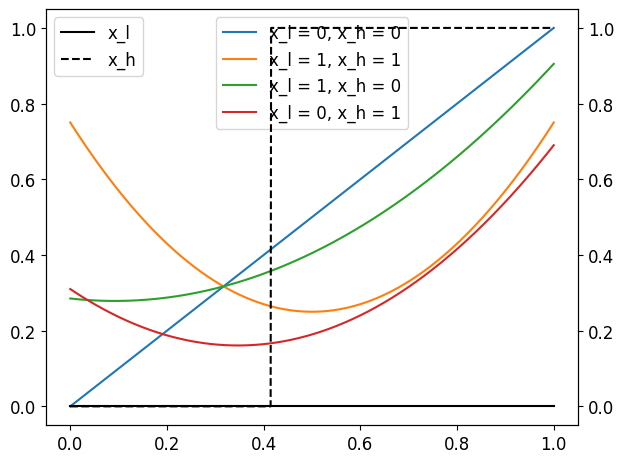

In [186]:
fig, ax = plt.subplots()

ax.plot(prob_state0s, calc1s, label="x_l = 0, x_h = 0")
ax.plot(prob_state0s, calc2s, label="x_l = 1, x_h = 1")
ax.plot(prob_state0s, calc3s, label="x_l = 1, x_h = 0")
ax.plot(prob_state0s, calc4s, label="x_l = 0, x_h = 1")


ax2 = ax.twinx()
ax2.plot(prob_state0s, xls, color="k", label="x_l")
ax2.plot(prob_state0s, xhs, color="k", ls="--", label="x_h")


ax.legend()
ax2.legend()

(-0.1, 1.1)

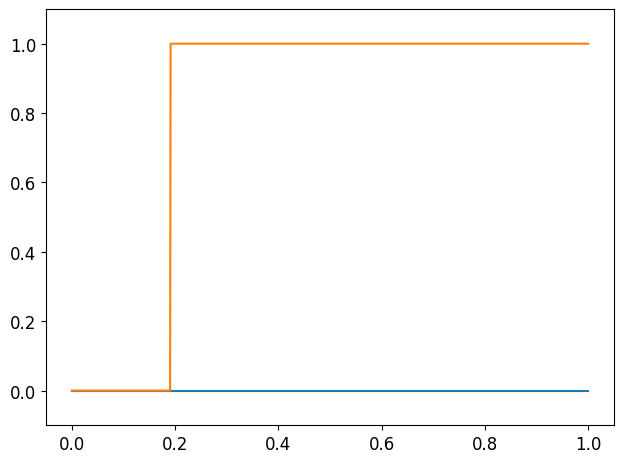

In [175]:
plt.plot(prob_state0s, xls)
plt.plot(prob_state0s, xhs)

plt.ylim([-0.1, 1.1])

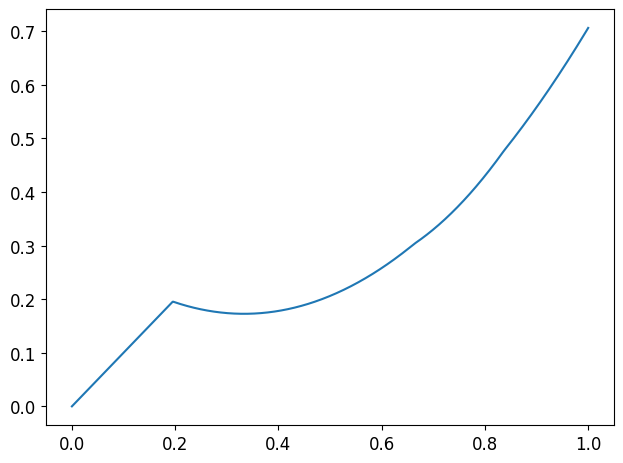

In [124]:
plt.plot(prob_state0s, funs)


In [27]:
def objective2(vars):
    x_l, trans_h, trans_l = vars
    x_h = 1
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_h - cost_h) - (1-gamma) * (trans_l - cost_l)


def constraint12(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_h) * (1 - x) - (trans_h - trans_l)


def constraint22(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_l) * (x - 1) - (trans_l - trans_h)


def constraint32(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_l) * x - trans_l

def constraint42(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_h) - trans_h

constraints = [
        {'type': 'ineq', 'fun': constraint12},
        #{'type': 'ineq', 'fun': constraint22},
        {'type': 'ineq', 'fun': constraint32},
        #{'type': 'ineq', 'fun': constraint42},
    ]
x0 = [1, 1, 1]
bounds = [(0, 1), (0, None), (0, None)]
result = minimize(
            objective2,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

    
result.x

array([7.90885027e-16, 4.90000000e-01, 0.00000000e+00])